<a href="https://colab.research.google.com/github/afllaabdi/tugas_NLP/blob/main/Source_Code.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# =========================
# IMPORT LIBRARY
# =========================
import pandas as pd
import matplotlib.pyplot as plt
from collections import Counter
import re

# Optional WordCloud
try:
    from wordcloud import WordCloud
    WORDCLOUD_AVAILABLE = True
except:
    WORDCLOUD_AVAILABLE = False

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [21]:
# =========================
# LOAD DATA
# =========================
file_path = '/content/drive/MyDrive/dataset/dataset_pangan.csv'

df = pd.read_csv(file_path)
df = df.rename(columns={'Content': 'text'})

print("Jumlah data:", df.shape)
df.head()

Jumlah data: (964, 1)


,text
0,Ferry Irwandi Cicip Aldi's Burger dan Daftar M...
1,"Harga Sembako Jatim Terbaru, Gas Naik, Cabai d..."
2,"Aceh Alami Inflasi 5,31% pada Maret, Tertinggi..."
3,Video: Komisi IV DPR Ungkap Biang Kerok Harga ...
4,"Maret Inflasi 0,41%, Harga Ayam hingga Telur J..."


In [22]:
# =========================
# DATA CLEANING
# =========================
def clean_text(text):
    text = text.lower()  # lowercase
    text = re.sub(r'[^a-zA-Z\s]', '', text)  # hapus simbol & angka
    return text

df['clean_text'] = df['text'].astype(str).apply(clean_text)

df[['text', 'clean_text']].head()

,text,clean_text
0,Ferry Irwandi Cicip Aldi's Burger dan Daftar M...,ferry irwandi cicip aldis burger dan daftar ma...
1,"Harga Sembako Jatim Terbaru, Gas Naik, Cabai d...",harga sembako jatim terbaru gas naik cabai dan...
2,"Aceh Alami Inflasi 5,31% pada Maret, Tertinggi...",aceh alami inflasi pada maret tertinggi di ac...
3,Video: Komisi IV DPR Ungkap Biang Kerok Harga ...,video komisi iv dpr ungkap biang kerok harga b...
4,"Maret Inflasi 0,41%, Harga Ayam hingga Telur J...",maret inflasi harga ayam hingga telur jadi pe...


In [23]:
# =========================
# NORMALIZATION (STOPWORD)
# =========================
from Sastrawi.StopWordRemover.StopWordRemoverFactory import StopWordRemoverFactory

factory = StopWordRemoverFactory()
stopwords = factory.create_stop_word_remover()

df['clean_text'] = df['clean_text'].apply(stopwords.remove)

df.head()

,text,clean_text
0,Ferry Irwandi Cicip Aldi's Burger dan Daftar M...,ferry irwandi cicip aldis burger daftar makana...
1,"Harga Sembako Jatim Terbaru, Gas Naik, Cabai d...",harga sembako jatim terbaru gas naik cabai dag...
2,"Aceh Alami Inflasi 5,31% pada Maret, Tertinggi...",aceh alami inflasi maret tertinggi aceh tengah
3,Video: Komisi IV DPR Ungkap Biang Kerok Harga ...,video komisi iv dpr ungkap biang kerok harga b...
4,"Maret Inflasi 0,41%, Harga Ayam hingga Telur J...",maret inflasi harga ayam hingga telur jadi pe...


In [24]:
# =========================
# DATA REDUCTION
# =========================
df = df.drop_duplicates()
df = df[['clean_text']]

print("Setelah reduction:", df.shape)

Setelah reduction: (732, 1)


In [ ]:
# =========================
# AUTO LABEL
# =========================
positive_words = ['stabil', 'turun', 'murah', 'aman', 'baik']
negative_words = ['naik', 'mahal', 'langka', 'krisis', 'inflasi']

def auto_label(text):
    score = 0

    for word in positive_words:
        if word in text:
            score += 1

    for word in negative_words:
        if word in text:
            score -= 1

    if score > 0:
        return 'positif'
    elif score < 0:
        return 'negatif'
    else:
        return 'netral'

df['label'] = df['clean_text'].apply(auto_label)

df.head()

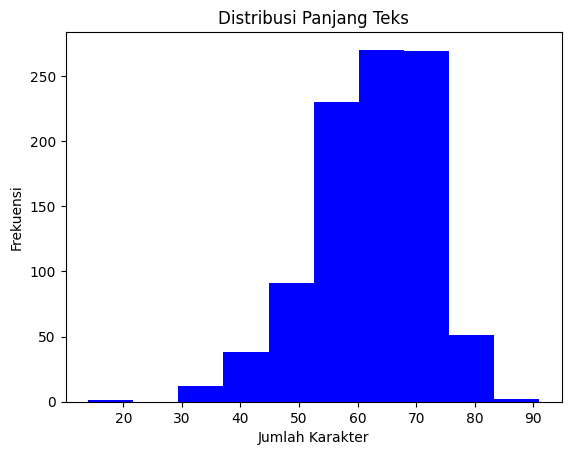

In [ ]:

# =========================
# 2. PANJANG TEKS (BIRU)
# =========================
df['text_length'] = df['clean_text'].apply(len)

plt.hist(df['text_length'], color='blue')
plt.title("Distribusi Panjang Teks")
plt.xlabel("Jumlah Karakter")
plt.ylabel("Frekuensi")
plt.show()

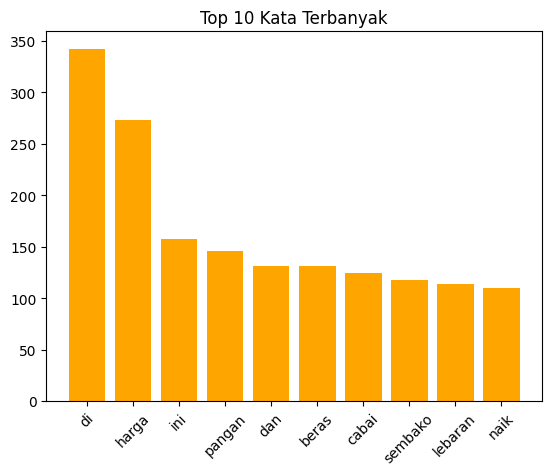

In [ ]:
# =========================
# 3. WORD FREQUENCY (ORANGE)
# =========================
all_text = " ".join(df['clean_text'])
words = all_text.split()
word_freq = Counter(words)

common_words = word_freq.most_common(10)
words = [w[0] for w in common_words]
counts = [w[1] for w in common_words]

plt.bar(words, counts, color='orange')
plt.title("Top 10 Kata Terbanyak")
plt.xticks(rotation=45)
plt.show()


In [ ]:

# =========================
# 4. WORDCLOUD
# =========================
if WORDCLOUD_AVAILABLE:
    wordcloud = WordCloud(width=800, height=400, colormap='viridis').generate(all_text)

    plt.imshow(wordcloud)
    plt.axis('off')
    plt.title("WordCloud")
    plt.show()

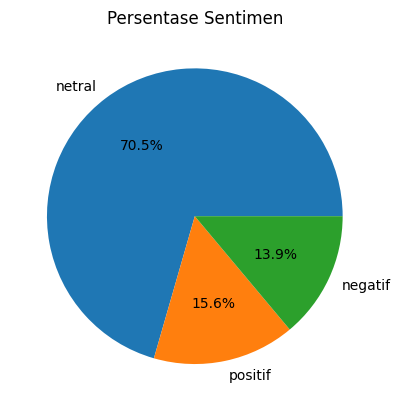

In [ ]:
df['label'].value_counts().plot(kind='pie', autopct='%1.1f%%')
plt.title("Persentase Sentimen")
plt.ylabel("")
plt.show()